In [1]:
"""
Process the small collar measured shrub-moss community NEE
Use May 15 - Oct 15 growing season mean value, with fitting RMSE as the uncertainty level
Unit: gC m-2 day-1
"""
import os
import matplotlib.pyplot as plt
import pandas as pd
import itertools as it
import numpy as np
from utils.nee_flux_partitioning import fit_nee_model, predict_nee, predict_reco, predict_gpp, plot_result

In [2]:
########################################################################
# (1) Collect the small collar measurements into well-formatted 
#     single dataframe
########################################################################

def read_2023():
    data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'input', 'Data and Guide for SPRUCE.104', 
                                    'SPRUCE_GHG_Flux_15_min_2023.csv'), 
                    index_col = 0, na_values = -9999, parse_dates=True)
    data = data.groupby(['date_time_30_min_CST', 'plot', 'warming_treatment', 'CO2_treatment', 'collar_number']).mean()
    data = data.drop(['julian_day','meanCH4_conc','meanCO2_conc','CH4_flux'], axis = 1).reset_index()

    # Reformat the data into consistency with 2022: the collar-specific measurements are 
    # indicated by Collar_1 & Collar_2 suffixes instead of a collar_number column

    # Columns that vary per collar
    collar_varying = ['CO2_flux', 'PAR', 'collar_soil_temp', 'collar_VWC']

    # Columns that are identical across collars (shared)
    shared_cols = [c for c in data.columns if c not in collar_varying + ['collar_number']]

    # Split by collar
    c1 = data[data['collar_number'] == 1].copy()
    c2 = data[data['collar_number'] == 2].copy()

    # Rename varying columns with suffix
    c1 = c1.rename(columns={col: f'{col}_Collar_1' for col in collar_varying})
    c2 = c2.rename(columns={col: f'{col}_Collar_2' for col in collar_varying})

    # Drop collar_number before merging
    c1 = c1.drop(columns=['collar_number'])
    c2 = c2.drop(columns=['collar_number'])[['date_time_30_min_CST', 'plot', 'warming_treatment', 'CO2_treatment'] + [f'{col}_Collar_2' for col in collar_varying]]

    # Merge on shared identifying columns
    merge_keys = ['date_time_30_min_CST', 'plot', 'warming_treatment', 'CO2_treatment']
    result = c1.merge(c2, on=merge_keys, how='outer')

    result['date_time_30_min_CST'] = pd.to_datetime(result['date_time_30_min_CST'])

    return result


def read_2022():
    data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'input', 'Data and Guide for SPRUCE.104', 
                                    'SPRUCE_GHG_Flux_30_min_2022.csv'), na_values = -9999)
    data = data.groupby(['date_time_30_min_CST', 'plot', 'warming_treatment', 'CO2_treatment']).mean()

    # 2022 data only has single PAR
    data['PAR_Collar_1'] = data['PAR']
    data['PAR_Collar_2'] = data['PAR']

    data = data.drop(['PAR','DOY','CH4_flux_Collar_1','CH4_flux_Collar_2'], axis = 1).reset_index()

    data['date_time_30_min_CST'] = pd.to_datetime(data['date_time_30_min_CST'])

    return data

# It turns out 2023 data is much more complete than 2022; 2022 only has a few months
# Focus on 2023 then
### data = pd.concat([read_2023(), read_2022()], axis = 0, ignore_index=True).sort_values(by=['warming_treatment','CO2_treatment','date_time_30_min_CST'])
data = read_2023().sort_values(by=['warming_treatment','CO2_treatment','date_time_30_min_CST'])

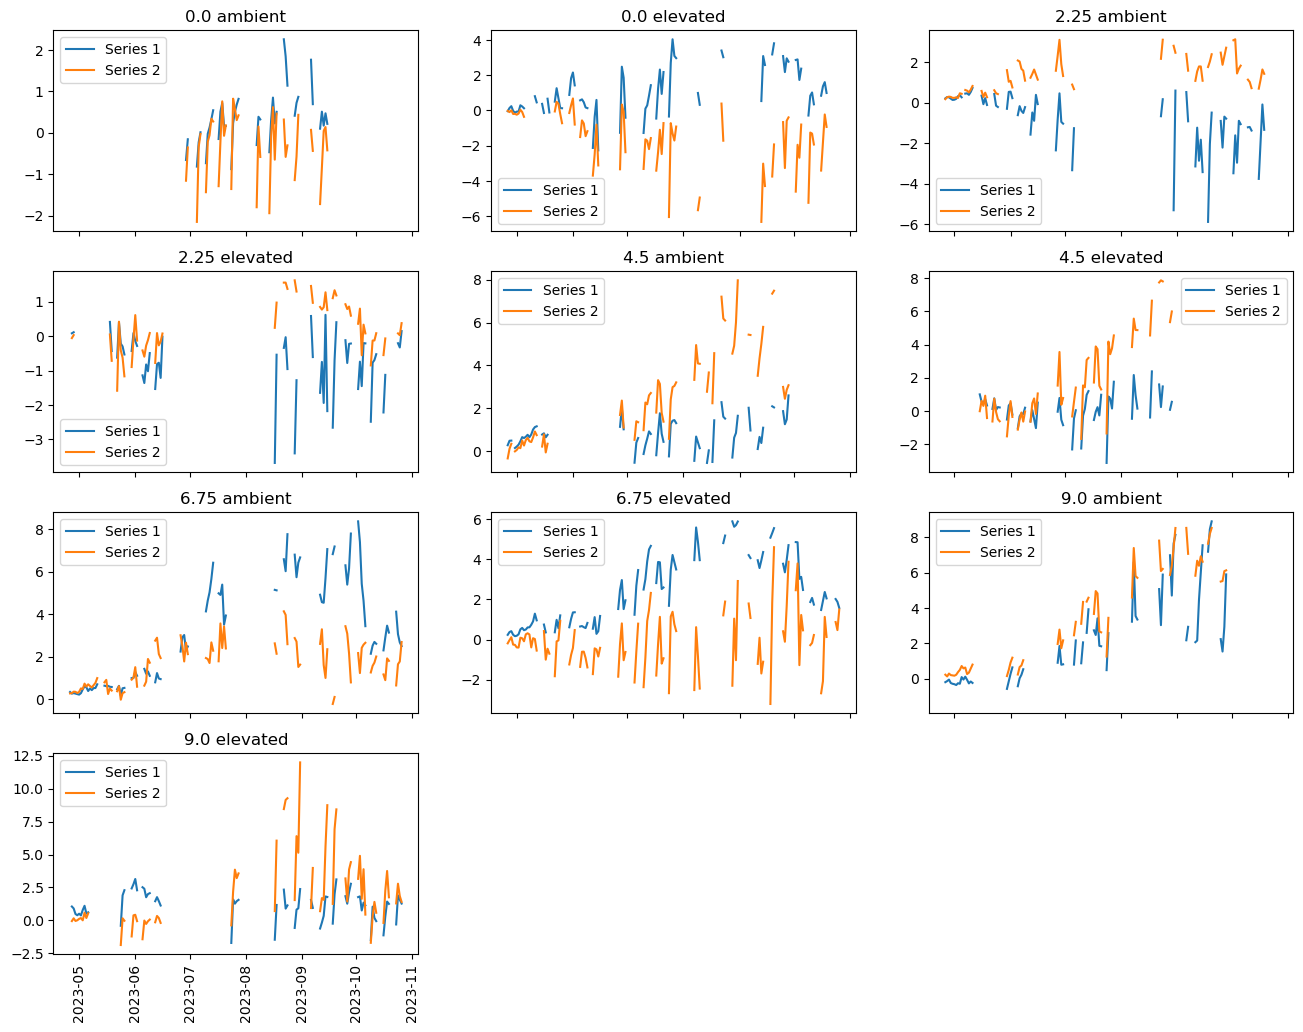

In [3]:
########################################################################
# (2) Examine the data availability across the two years
########################################################################
warming_list = data['warming_treatment'].drop_duplicates().sort_values().values
co2_list = data['CO2_treatment'].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize = (16, 12), sharex = True, sharey = False)
count = 0
for warming, co2 in it.product(warming_list, co2_list):
    subset = data.query('warming_treatment == @warming and CO2_treatment == @co2').set_index('date_time_30_min_CST')
    subset_1 = subset['CO2_flux_Collar_1'].resample('1D').apply(lambda x: x.mean() if x.notna().sum() >= 24 else np.nan)
    subset_2 = subset['CO2_flux_Collar_2'].resample('1D').apply(lambda x: x.mean() if x.notna().sum() >= 24 else np.nan)

    # convert unit from umol m-2 s-1 => gC m-2 day-1
    subset_1 *= (86400 * 12 * 1e-6)
    subset_2 *= (86400 * 12 * 1e-6)

    #
    ax = axes.flat[count]
    ax.plot(subset_1.index, subset_1.values, '-', label = 'Series 1')
    ax.plot(subset_2.index, subset_2.values, '-', label = 'Series 2')
    ax.legend()

    ax.set_title(f'{warming} {co2}')

    count = count + 1

    plt.setp(ax.get_xticklabels(), rotation = 90)

for i in range(count, len(axes.flat)):
    axes.flat[i].axis('off')

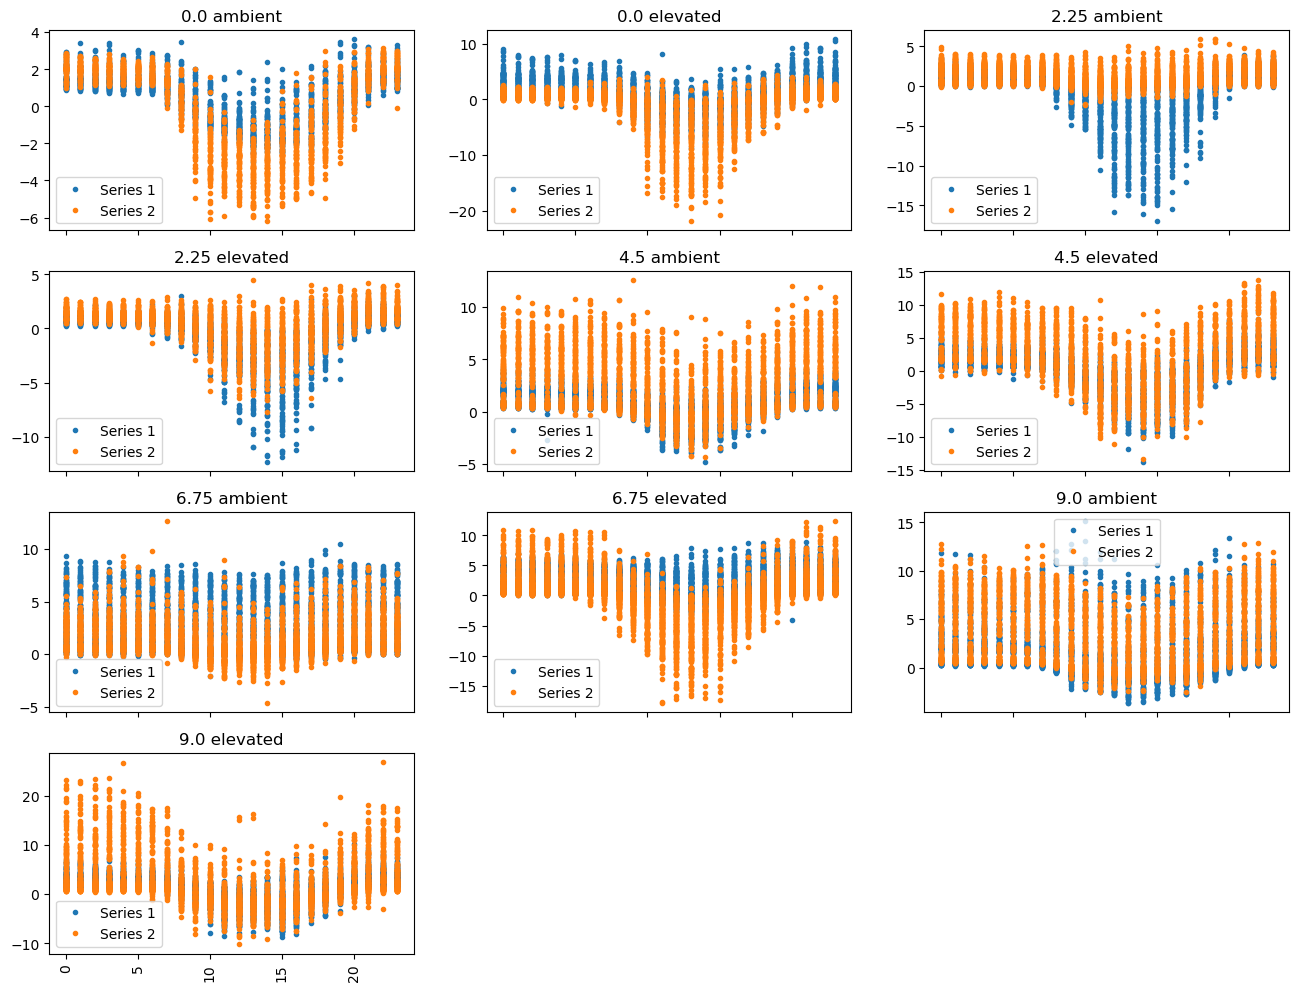

In [4]:
########################################################################
# (3) Examine the GPP-induced diurnal cycle
########################################################################

warming_list = data['warming_treatment'].drop_duplicates().sort_values().values
co2_list = data['CO2_treatment'].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize = (16, 12), sharex = True, sharey = False)
count = 0
for warming, co2 in it.product(warming_list, co2_list):
    subset = data.query('warming_treatment == @warming and CO2_treatment == @co2').set_index('date_time_30_min_CST')
    # subset = subset.loc[subset['PAR'] < 1]

    #
    ax = axes.flat[count]
    ax.plot(subset.index.hour, subset['CO2_flux_Collar_1'], 'o', label = 'Series 1', markersize = 3)
    ax.plot(subset.index.hour, subset['CO2_flux_Collar_2'], 'o', label = 'Series 2', markersize = 3)
    ax.legend()

    ax.set_title(f'{warming} {co2}')

    count = count + 1

    plt.setp(ax.get_xticklabels(), rotation = 90)

for i in range(count, len(axes.flat)):
    axes.flat[i].axis('off')

In [5]:
########################################################################
# (4) Use flux partitioning to gap fill to whole year
#     Since 2023 has much better observations, fit using 2022+2023, but
#     retrieve only for 2023. Give uncertainty estimate.
#
# Fit the parameters separately for each chamber
########################################################################
warming_list = data['warming_treatment'].drop_duplicates().sort_values().values
co2_list = data['CO2_treatment'].drop_duplicates().values

# (4.1) Model fitting and diagnostics
collect_result = {}
for warming, co2 in it.product(warming_list, co2_list):
    subset = data.query('warming_treatment == @warming and CO2_treatment == @co2').set_index('date_time_30_min_CST')

    subset_1 = subset[['PAR_Collar_1','collar_soil_temp_Collar_1','CO2_flux_Collar_1']].dropna(axis=0,how='any')
    subset_2 = subset[['PAR_Collar_2','collar_soil_temp_Collar_1','CO2_flux_Collar_2']].dropna(axis=0,how='any')
    subset = np.concatenate([subset_1.values, subset_2.values], axis = 0)

    result_sim = fit_nee_model(subset[:,0], subset[:,1]+273.15, subset[:,2], verbose = False, method='simultaneous')
    result_2s = fit_nee_model(subset[:,0], subset[:,1]+273.15, subset[:,2], verbose = False, method='two_step')

    collect_result[(warming, co2)] = result_sim # because either method is similar, use result_sim for its simplicity

    fig = plot_result(result_sim, result_2s, np.concatenate([subset_1.index.hour, subset_2.index.hour], axis = 0), subset[:,0], subset[:,1]+273.15, subset[:,2])
    plt.savefig(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                             'extract_obs_small_collar', f'nee_fit_{warming}_{co2}.png'), dpi=150)
    plt.close(fig)


# (4.2) Gapfill the NEE (=HR - NPP)
NEE = {}
plot_list = data['plot'].drop_duplicates()
for plot in plot_list:
    warming = data.loc[data['plot'] == plot, 'warming_treatment'].values[0]
    co2 = data.loc[data['plot'] == plot, 'CO2_treatment'].values[0]

    # Obtain the PAR and 5-10cm soil temperature from complete environmental data
    env_data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'input', 'WEW_Complete_Environ_20250311',
                                        f'WEW PLOT_{plot[1:]}_Complete_Environ_20250311.csv'),
                           na_values = -9999)
    env_data = env_data[['TIMESTAMP','TS_5_B2','TS_10_B3','PAR_2']].dropna(axis = 0, how = 'any')
    env_data['TIMESTAMP'] = pd.to_datetime(env_data['TIMESTAMP'])
    env_data = env_data.loc[env_data['TIMESTAMP'].dt.year == 2023, :]

    # Obtain the modeled values from the fitted equation
    nee_modeled = predict_nee(env_data['PAR_2'].values,
                              0.5 * (env_data['TS_5_B2'] + env_data['TS_10_B3']).values + 273.15,
                              collect_result[(warming, co2)]['params'])

    # Use the original values where observations exist
    nee_original = data.query('warming_treatment == @warming and CO2_treatment == @co2'
                             ).set_index('date_time_30_min_CST')[['CO2_flux_Collar_1','CO2_flux_Collar_2']].mean(axis = 1)
    nee_original = nee_original.dropna()

    #
    nee_gapfilled = pd.Series(nee_modeled, index = env_data['TIMESTAMP'])
    nee_gapfilled = pd.concat([nee_original, nee_gapfilled])
    nee_gapfilled = nee_gapfilled[~nee_gapfilled.index.duplicated(keep='first')]

    #
    NEE[(warming, co2)] = nee_gapfilled
NEE = pd.DataFrame(NEE)

### Convert to 5/15-10/15 mean to capture the mean value during the
###     measurement period and growing season
# Convert to JJA since we assumed a GPP max and it is the high growing season?
NEE = NEE.loc[(NEE.index >= pd.Timestamp('2023/06/01 00:00:00')) & \
              (NEE.index <= pd.Timestamp('2023/08/31 23:30:00')), :]
NEE.to_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                            'extract_obs_small_collar', 'nee_gapfill_outcome.csv'))

# Also save the growing season average and uncertainty
# The simplest approach: use the RMSE of the fit as a constant standard deviation 
# for all gap-filled values, and zero for observed values.
NEE_mean = NEE.mean(axis = 0).to_frame('growing season mean')
NEE_mean['uncertainty (rmse)'] = np.full(len(NEE_mean), np.nan)
for warming, co2 in it.product(warming_list, co2_list):
    NEE_mean.loc[(warming, co2), 'uncertainty (rmse)'] = collect_result[(warming,co2)]['rmse']
# (add plot label)
plot_indexing = data[['plot','warming_treatment','CO2_treatment']].drop_duplicates().set_index(['warming_treatment','CO2_treatment'])
NEE_mean['plot'] = [plot_indexing.loc[(warming,co2)].values[0] for warming,co2 in NEE_mean.index]
NEE_mean.to_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                            'extract_obs_small_collar', 'nee_gapfill_outcome_growing_season_mean.csv'))

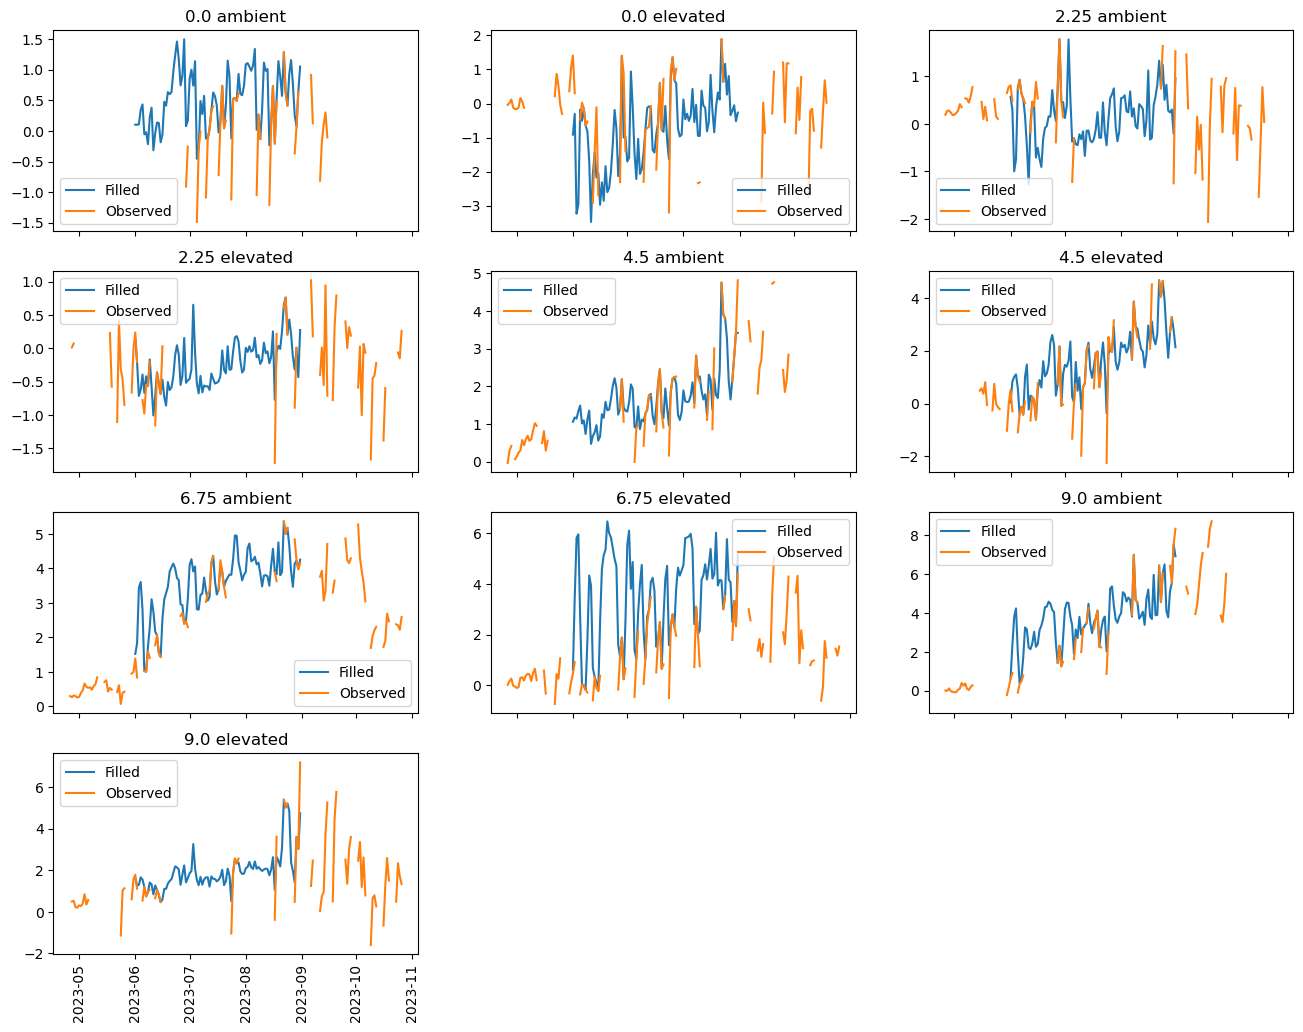

In [6]:
########################################################################
# (5) Examine the data availability after gap filling
########################################################################
warming_list = data['warming_treatment'].drop_duplicates().sort_values().values
co2_list = data['CO2_treatment'].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize = (16, 12), sharex = True, sharey = False)
count = 0
for warming, co2 in it.product(warming_list, co2_list):
    # convert unit from umol m-2 s-1 => gC m-2 day-1
    filled = NEE[(warming, co2)].resample('1D').mean() * (86400 * 12 * 1e-6)

    # convert unit from umol m-2 s-1 => gC m-2 day-1
    subset = data.query('warming_treatment == @warming and CO2_treatment == @co2').set_index('date_time_30_min_CST')
    subset_1 = subset['CO2_flux_Collar_1'].resample('1D').apply(lambda x: x.mean() if x.notna().sum() >= 24 else np.nan)
    subset_2 = subset['CO2_flux_Collar_2'].resample('1D').apply(lambda x: x.mean() if x.notna().sum() >= 24 else np.nan)
    subset = 0.5*(subset_1 + subset_2)*86400 * 12 * 1e-6

    #
    ax = axes.flat[count]
    ax.plot(filled.index, filled.values, '-', label = 'Filled')
    ax.plot(subset.index, subset.values, '-', label = 'Observed')
    ax.legend()

    ax.set_title(f'{warming} {co2}')

    count = count + 1

    plt.setp(ax.get_xticklabels(), rotation = 90)

for i in range(count, len(axes.flat)):
    axes.flat[i].axis('off')

plt.savefig(os.path.join(os.environ['PROJDIR'], 'ELM_Nutrients', 'output', 'extract',
                            'extract_obs_small_collar', f'nee_gapfill_outcome.png'), dpi=150)